# HW2 – Detect AI Generated Text
**Course:** RNN and Transformer  
**Hardware:** NVIDIA RTX 4090 (24GB VRAM)

This notebook covers all parts of the assignment:
1. **Part 1** — Data Analysis & Baseline (EDA + TF-IDF + Logistic Regression)
2. **Part 2** — BERT Fine-Tuning & Scaling (bert-base-cased vs bert-large-cased)
3. **Part 3** — Adversarial Attack with Local LLM (Ollama + DeepSeek-R1)
4. **Part 4** — Analysis Report & Comparison

---
# Part 1: Data Analysis & Baseline (20%)

- Exploratory Data Analysis (EDA): word count, vocabulary richness, sentence count, avg word length
- Classic Baseline: TF-IDF + Logistic Regression
- Report: ROC-AUC score as benchmark for BERT models

## 1.1 Imports & Configuration

In [1]:
import os
import re
import json
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report, roc_curve
)

DATA_PATH = os.path.join("DAIGT V2 Train Dataset", "train_v2_drcat_02.csv")
OUTPUT_DIR_BASELINE = "results_baseline"
RANDOM_STATE = 42
os.makedirs(OUTPUT_DIR_BASELINE, exist_ok=True)

print("Part 1: Data Analysis & Baseline")
print("=" * 60)

Part 1: Data Analysis & Baseline


## 1.2 Load Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
df = df[['text', 'label']].dropna(subset=['text', 'label'])
df['label'] = df['label'].astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Label distribution:")
print(f"  Label 0 (Human): {(df['label'] == 0).sum()}")
print(f"  Label 1 (AI):    {(df['label'] == 1).sum()}")
df.head()

Dataset shape: (44868, 2)
Label distribution:
  Label 0 (Human): 27371
  Label 1 (AI):    17497


,text,label
0,Phones\n\nModern humans today are always on th...,0
1,This essay will explain if drivers should or s...,0
2,Driving while the use of cellular devices\n\nT...,0
3,Phones & Driving\n\nDrivers should not be able...,0
4,Cell Phone Operation While Driving\n\nThe abil...,0


## 1.3 Exploratory Data Analysis (EDA)

Compare **word count**, **vocabulary richness (Type-Token Ratio)**, **sentence count**, and **average word length** between human and AI texts.

In [3]:
# --- Word count ---
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
human_wc = df[df['label'] == 0]['word_count']
ai_wc = df[df['label'] == 1]['word_count']

print("Word Count Statistics:")
print(f"  Human – mean: {human_wc.mean():.1f}, median: {human_wc.median():.1f}, std: {human_wc.std():.1f}")
print(f"  AI    – mean: {ai_wc.mean():.1f}, median: {ai_wc.median():.1f}, std: {ai_wc.std():.1f}")

# --- Vocabulary richness (Type-Token Ratio) ---
def type_token_ratio(text):
    words = str(text).lower().split()
    return len(set(words)) / len(words) if words else 0.0

df['ttr'] = df['text'].apply(type_token_ratio)
human_ttr = df[df['label'] == 0]['ttr']
ai_ttr = df[df['label'] == 1]['ttr']

print(f"\nVocabulary Richness (Type-Token Ratio):")
print(f"  Human – mean: {human_ttr.mean():.4f}, median: {human_ttr.median():.4f}")
print(f"  AI    – mean: {ai_ttr.mean():.4f}, median: {ai_ttr.median():.4f}")

# --- Sentence count ---
df['sentence_count'] = df['text'].apply(lambda x: len(re.split(r'[.!?]+', str(x))))
human_sc = df[df['label'] == 0]['sentence_count']
ai_sc = df[df['label'] == 1]['sentence_count']

print(f"\nSentence Count Statistics:")
print(f"  Human – mean: {human_sc.mean():.1f}, median: {human_sc.median():.1f}")
print(f"  AI    – mean: {ai_sc.mean():.1f}, median: {ai_sc.median():.1f}")

# --- Average word length ---
def avg_word_length(text):
    words = str(text).split()
    return np.mean([len(w) for w in words]) if words else 0.0

df['avg_word_len'] = df['text'].apply(avg_word_length)
human_awl = df[df['label'] == 0]['avg_word_len']
ai_awl = df[df['label'] == 1]['avg_word_len']

print(f"\nAverage Word Length:")
print(f"  Human – mean: {human_awl.mean():.2f}")
print(f"  AI    – mean: {ai_awl.mean():.2f}")

Word Count Statistics:
  Human – mean: 418.3, median: 383.0, std: 189.3
  AI    – mean: 329.4, median: 328.0, std: 94.3

Vocabulary Richness (Type-Token Ratio):
  Human – mean: 0.4785, median: 0.4785
  AI    – mean: 0.5104, median: 0.5000

Sentence Count Statistics:
  Human – mean: 22.3, median: 21.0
  AI    – mean: 19.1, median: 19.0

Average Word Length:
  Human – mean: 4.53
  AI    – mean: 5.09


## 1.4 EDA Visualizations

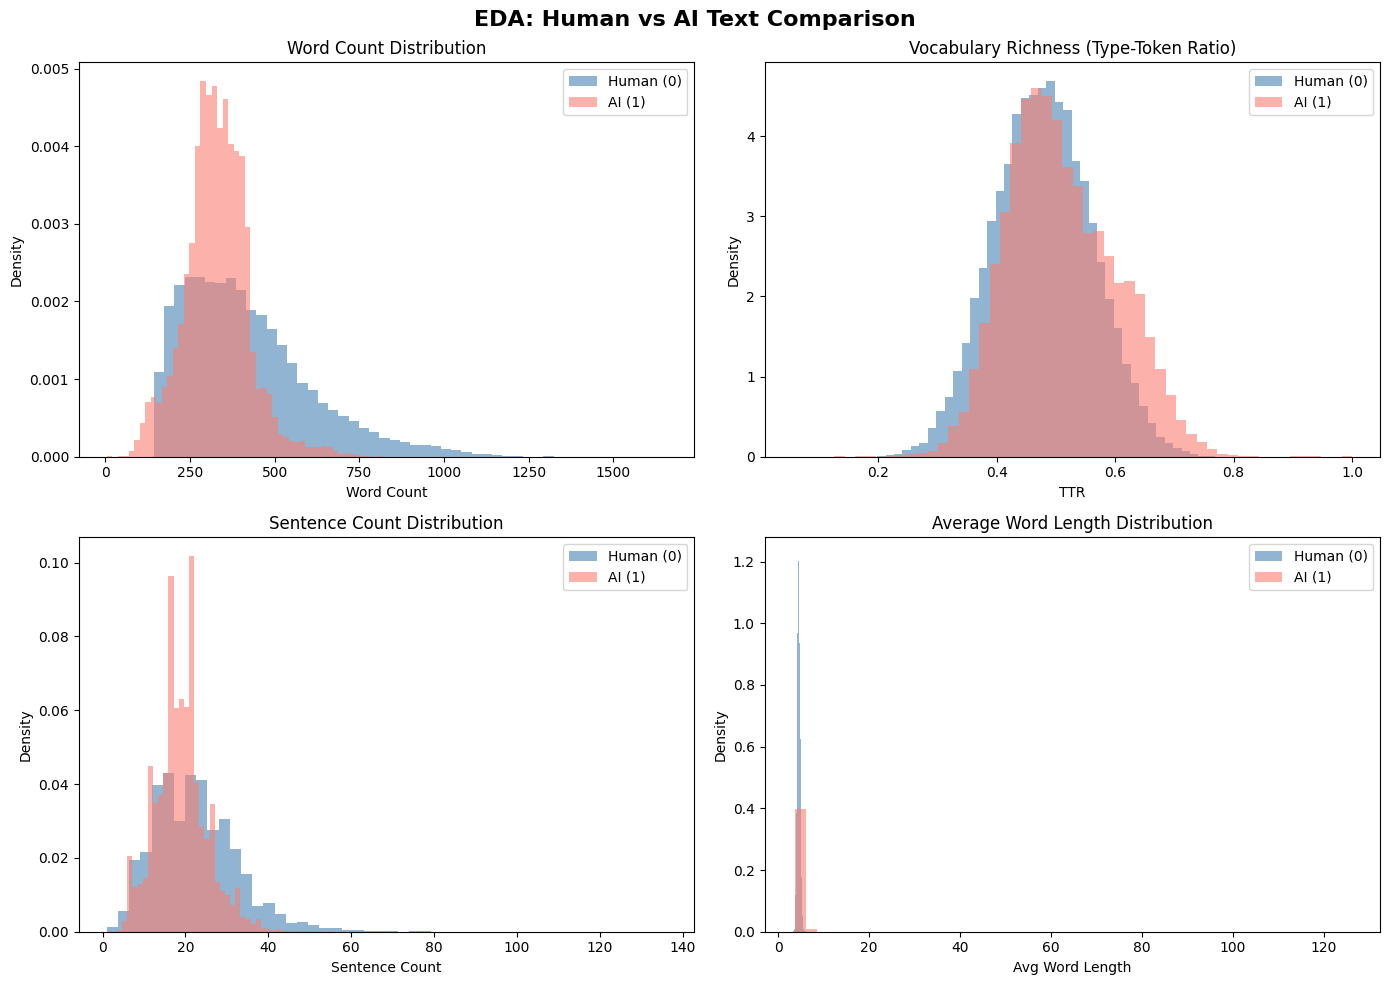

Saved: results_baseline/eda_distributions.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA: Human vs AI Text Comparison", fontsize=16, fontweight='bold')

axes[0, 0].hist(human_wc, bins=50, alpha=0.6, label='Human (0)', color='steelblue', density=True)
axes[0, 0].hist(ai_wc, bins=50, alpha=0.6, label='AI (1)', color='salmon', density=True)
axes[0, 0].set_title('Word Count Distribution')
axes[0, 0].set_xlabel('Word Count'); axes[0, 0].set_ylabel('Density'); axes[0, 0].legend()

axes[0, 1].hist(human_ttr, bins=50, alpha=0.6, label='Human (0)', color='steelblue', density=True)
axes[0, 1].hist(ai_ttr, bins=50, alpha=0.6, label='AI (1)', color='salmon', density=True)
axes[0, 1].set_title('Vocabulary Richness (Type-Token Ratio)')
axes[0, 1].set_xlabel('TTR'); axes[0, 1].set_ylabel('Density'); axes[0, 1].legend()

axes[1, 0].hist(human_sc, bins=50, alpha=0.6, label='Human (0)', color='steelblue', density=True)
axes[1, 0].hist(ai_sc, bins=50, alpha=0.6, label='AI (1)', color='salmon', density=True)
axes[1, 0].set_title('Sentence Count Distribution')
axes[1, 0].set_xlabel('Sentence Count'); axes[1, 0].set_ylabel('Density'); axes[1, 0].legend()

axes[1, 1].hist(human_awl, bins=50, alpha=0.6, label='Human (0)', color='steelblue', density=True)
axes[1, 1].hist(ai_awl, bins=50, alpha=0.6, label='AI (1)', color='salmon', density=True)
axes[1, 1].set_title('Average Word Length Distribution')
axes[1, 1].set_xlabel('Avg Word Length'); axes[1, 1].set_ylabel('Density'); axes[1, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_BASELINE, "eda_distributions.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR_BASELINE}/eda_distributions.png")

## 1.5 Train/Validation Split & TF-IDF + Logistic Regression Baseline

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=RANDOM_STATE, stratify=df['label']
)
print(f"Train set: {len(X_train)} samples")
print(f"Val set:   {len(X_val)} samples")

# TF-IDF + Logistic Regression
print("\nTraining TF-IDF + Logistic Regression...")
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

clf = LogisticRegression(solver='liblinear', max_iter=1000, C=1.0)
clf.fit(X_train_tfidf, y_train)

preds_proba = clf.predict_proba(X_val_tfidf)[:, 1]
preds_label = clf.predict(X_val_tfidf)

baseline_auc = roc_auc_score(y_val, preds_proba)
baseline_acc = accuracy_score(y_val, preds_label)

print(f"\n{'='*40}")
print(f"Baseline TF-IDF + LR Results:")
print(f"  ROC-AUC:  {baseline_auc:.4f}")
print(f"  Accuracy: {baseline_acc:.4f}")
print(f"{'='*40}")
print(f"\n{classification_report(y_val, preds_label, target_names=['Human (0)', 'AI (1)'])}")

Train set: 35894 samples
Val set:   8974 samples

Training TF-IDF + Logistic Regression...

Baseline TF-IDF + LR Results:
  ROC-AUC:  0.9993
  Accuracy: 0.9939

              precision    recall  f1-score   support

   Human (0)       0.99      1.00      0.99      5474
      AI (1)       1.00      0.99      0.99      3500

    accuracy                           0.99      8974
   macro avg       0.99      0.99      0.99      8974
weighted avg       0.99      0.99      0.99      8974



## 1.6 Baseline ROC Curve

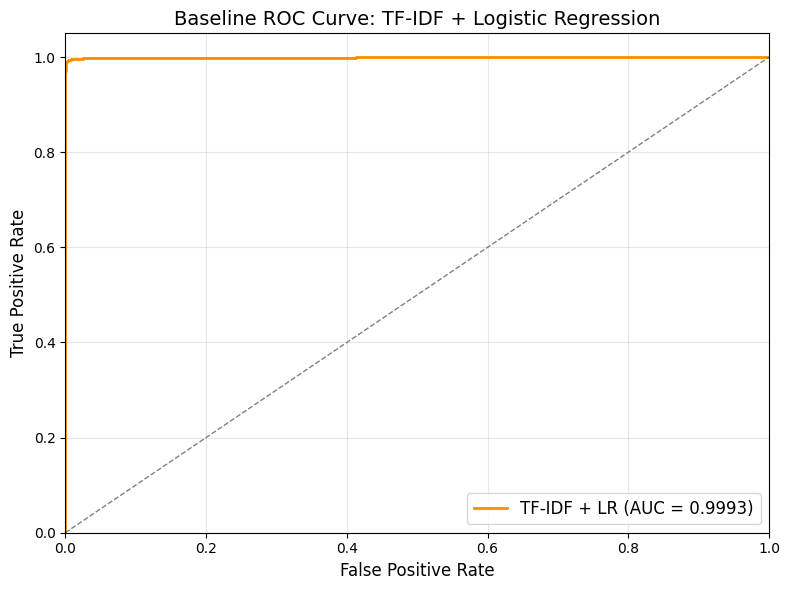

Saved: results_baseline/baseline_roc_curve.png


In [6]:
fpr, tpr, _ = roc_curve(y_val, preds_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'TF-IDF + LR (AUC = {baseline_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Baseline ROC Curve: TF-IDF + Logistic Regression', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_BASELINE, "baseline_roc_curve.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR_BASELINE}/baseline_roc_curve.png")

In [7]:
# Save data split for Part 2 & Part 3
split_data = {
    'X_train': X_train.reset_index(drop=True),
    'X_val': X_val.reset_index(drop=True),
    'y_train': y_train.reset_index(drop=True),
    'y_val': y_val.reset_index(drop=True),
}
with open(os.path.join(OUTPUT_DIR_BASELINE, "data_split.pkl"), 'wb') as f:
    pickle.dump(split_data, f)
print(f"Data split saved to {OUTPUT_DIR_BASELINE}/data_split.pkl")
print(f"\n✓ Baseline ROC-AUC = {baseline_auc:.4f} — benchmark for BERT models.")

Data split saved to results_baseline/data_split.pkl

✓ Baseline ROC-AUC = 0.9993 — benchmark for BERT models.


## 1.7 Enhanced EDA: Statistical Hypothesis Testing

Use **Mann-Whitney U test** (non-parametric) to determine whether the observed differences between human and AI text features are statistically significant. Also compute **Cohen's d** effect size.

In [24]:
from scipy import stats

features = {
    'Word Count': (human_wc, ai_wc),
    'Type-Token Ratio': (human_ttr, ai_ttr),
    'Sentence Count': (human_sc, ai_sc),
    'Avg Word Length': (human_awl, ai_awl),
}

print("=" * 75)
print("STATISTICAL HYPOTHESIS TESTING: Human vs AI Text Features")
print("=" * 75)
print(f"{'Feature':<20} {'U-statistic':>14} {'p-value':>14} {'Cohen d':>10} {'Significant':>12}")
print("-" * 75)

for feat_name, (human_vals, ai_vals) in features.items():
    # Mann-Whitney U Test (non-parametric)
    u_stat, p_val = stats.mannwhitneyu(human_vals, ai_vals, alternative='two-sided')
    
    # Cohen's d effect size
    pooled_std = np.sqrt((human_vals.std()**2 + ai_vals.std()**2) / 2)
    cohens_d = (human_vals.mean() - ai_vals.mean()) / pooled_std if pooled_std > 0 else 0
    
    sig = "YES ***" if p_val < 0.001 else ("YES **" if p_val < 0.01 else ("YES *" if p_val < 0.05 else "NO"))
    print(f"{feat_name:<20} {u_stat:>14.0f} {p_val:>14.2e} {cohens_d:>+10.3f} {sig:>12}")

print("-" * 75)
print("Effect size: |d| < 0.2 = negligible, 0.2-0.5 = small, 0.5-0.8 = medium, > 0.8 = large")
print("Significance: * p<0.05, ** p<0.01, *** p<0.001")

STATISTICAL HYPOTHESIS TESTING: Human vs AI Text Features
Feature                 U-statistic        p-value    Cohen d  Significant
---------------------------------------------------------------------------
Word Count                299569376       0.00e+00     +0.594      YES ***
Type-Token Ratio          196180450      1.99e-229     -0.366      YES ***
Sentence Count            281487067      7.11e-217     +0.384      YES ***
Avg Word Length            82604020       0.00e+00     -0.733      YES ***
---------------------------------------------------------------------------
Effect size: |d| < 0.2 = negligible, 0.2-0.5 = small, 0.5-0.8 = medium, > 0.8 = large
Significance: * p<0.05, ** p<0.01, *** p<0.001


## 1.8 Additional Baselines: SVM, Naive Bayes, Random Forest

Compare the TF-IDF + Logistic Regression baseline against other classic ML classifiers to establish a comprehensive baseline landscape.

BASELINE MODEL COMPARISON (TF-IDF features)
Model                        ROC-AUC   Accuracy  Precision     Recall         F1
----------------------------------------------------------------------
Logistic Regression           0.9993     0.9939     0.9980     0.9863     0.9921
Linear SVM                    0.9997     0.9970     0.9971     0.9951     0.9961
Multinomial NB                0.9955     0.9692     0.9781     0.9423     0.9598
Random Forest                 0.9987     0.9884     0.9968     0.9734     0.9850


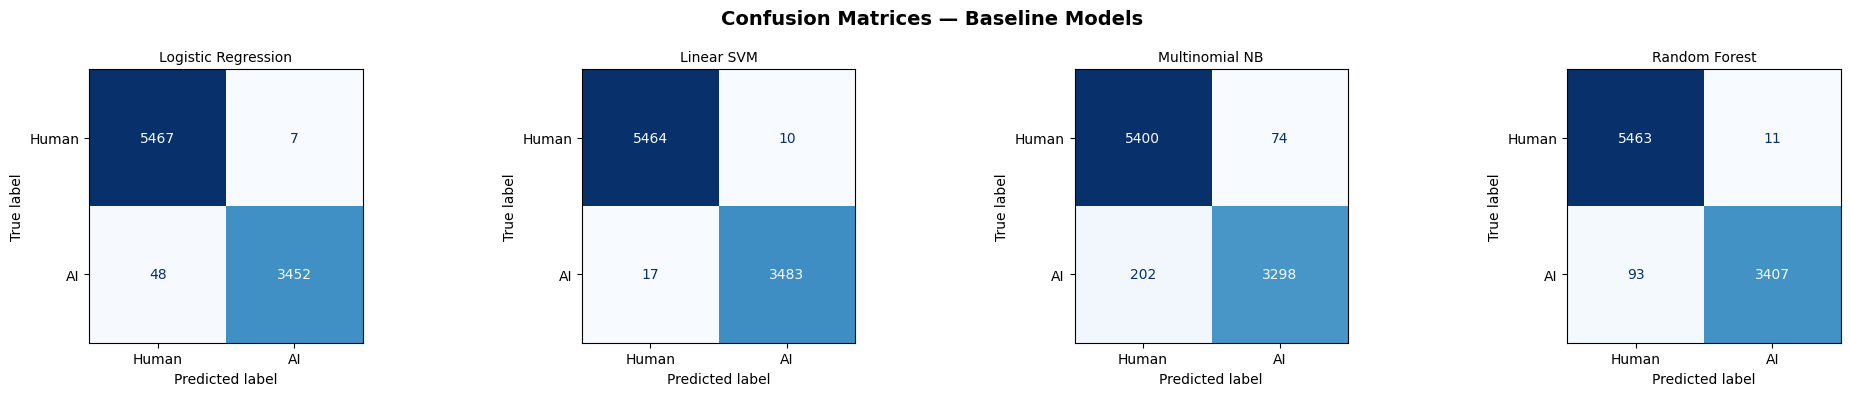

Saved: results_baseline/baseline_confusion_matrices.png


In [25]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classifiers = {
    "Logistic Regression": LogisticRegression(solver='liblinear', max_iter=1000, C=1.0),
    "Linear SVM": CalibratedClassifierCV(LinearSVC(max_iter=2000, C=1.0)),
    "Multinomial NB": MultinomialNB(alpha=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=50, random_state=42, n_jobs=-1),
}

baseline_results = {}
print("=" * 70)
print("BASELINE MODEL COMPARISON (TF-IDF features)")
print("=" * 70)
print(f"{'Model':<25} {'ROC-AUC':>10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 70)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for idx, (name, model) in enumerate(classifiers.items()):
    model.fit(X_train_tfidf, y_train)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_val_tfidf)[:, 1]
    else:
        proba = model.decision_function(X_val_tfidf)
    preds = model.predict(X_val_tfidf)
    
    auc_score = roc_auc_score(y_val, proba)
    acc = accuracy_score(y_val, preds)
    from sklearn.metrics import precision_score, recall_score, f1_score
    prec = precision_score(y_val, preds)
    rec = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    baseline_results[name] = {"auc": auc_score, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "proba": proba, "preds": preds}
    print(f"{name:<25} {auc_score:>10.4f} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_val, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Human", "AI"]).plot(ax=axes[idx], cmap="Blues", colorbar=False)
    axes[idx].set_title(name, fontsize=10)

print("=" * 70)
plt.suptitle("Confusion Matrices — Baseline Models", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_BASELINE, "baseline_confusion_matrices.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR_BASELINE}/baseline_confusion_matrices.png")

## 1.9 Feature Correlation Analysis & ROC Comparison

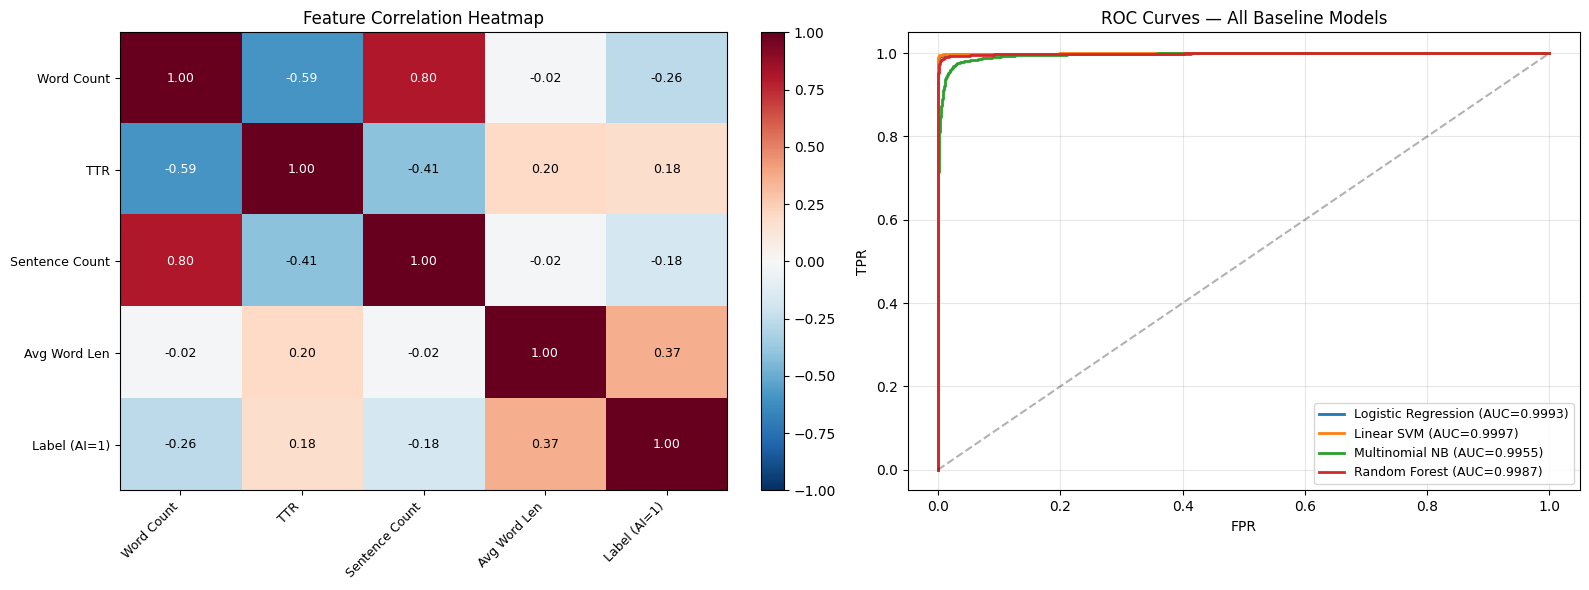

Saved: results_baseline/enhanced_eda.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Feature Correlation Heatmap
feat_df = df[['word_count', 'ttr', 'sentence_count', 'avg_word_len', 'label']].copy()
feat_df.columns = ['Word Count', 'TTR', 'Sentence Count', 'Avg Word Len', 'Label (AI=1)']
corr = feat_df.corr()
im = axes[0].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(corr.columns)))
axes[0].set_yticks(range(len(corr.columns)))
axes[0].set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[0].text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
axes[0].set_title('Feature Correlation Heatmap', fontsize=12)
plt.colorbar(im, ax=axes[0], fraction=0.046)

# (b) ROC curves for all baselines
for name, res in baseline_results.items():
    fpr_m, tpr_m, _ = roc_curve(y_val, res['proba'])
    axes[1].plot(fpr_m, tpr_m, label=f"{name} (AUC={res['auc']:.4f})", lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curves — All Baseline Models', fontsize=12)
axes[1].legend(loc='lower right', fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_BASELINE, "enhanced_eda.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR_BASELINE}/enhanced_eda.png")

---
# Part 2: BERT Fine-Tuning & Scaling (40%)

- **Model A (Base):** `bert-base-cased` (110M parameters)
- **Model B (Large):** `bert-large-cased` (340M parameters)
- Training with fp16 mixed precision on RTX 4090
- Evaluate using ROC-AUC on the same validation set from Part 1

## 2.1 BERT Imports & Helper Function

In [10]:
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
)
from transformers.utils.notebook import NotebookProgressCallback
from datasets import Dataset

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

# Load data split from Part 1
with open(os.path.join(OUTPUT_DIR_BASELINE, "data_split.pkl"), 'rb') as f:
    split_data = pickle.load(f)
X_train_text = split_data['X_train']
X_val_text = split_data['X_val']
y_train_labels = split_data['y_train']
y_val_labels = split_data['y_val']

print(f"Train: {len(X_train_text)} samples, Val: {len(X_val_text)} samples")


def train_bert_model(model_name, batch_size, max_len=512, epochs=3, lr=2e-5):
    """Train and evaluate a BERT model, return results dict."""
    output_dir = f"results_{model_name}"
    save_dir = f"saved_model_{model_name}"
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(save_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"  Batch={batch_size}, MaxLen={max_len}, Epochs={epochs}, LR={lr}")
    print(f"{'='*60}")

    # Build HF datasets
    hf_train = Dataset.from_pandas(
        pd.DataFrame({'text': X_train_text, 'label': y_train_labels}).reset_index(drop=True))
    hf_val = Dataset.from_pandas(
        pd.DataFrame({'text': X_val_text, 'label': y_val_labels}).reset_index(drop=True))

    # Tokenize
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    def tok_fn(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=max_len)
    tok_train = hf_train.map(tok_fn, batched=True, batch_size=256, desc=f"Tokenizing train ({model_name})")
    tok_val = hf_val.map(tok_fn, batched=True, batch_size=256, desc=f"Tokenizing val ({model_name})")
    tok_train.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    tok_val.set_format("torch", columns=["input_ids", "attention_mask", "label"])

    # Model
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Params: {total_params:,} total, {trainable_params:,} trainable")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
        preds = np.argmax(logits, axis=-1)
        return {"roc_auc": roc_auc_score(labels, probs), "accuracy": accuracy_score(labels, preds)}

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch", save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        num_train_epochs=epochs,
        weight_decay=0.01, fp16=True,
        logging_steps=50, logging_dir=os.path.join(output_dir, "logs"),
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="roc_auc", greater_is_better=True,
        save_total_limit=2, dataloader_num_workers=0, warmup_ratio=0.1,
    )

    trainer = Trainer(
        model=model, args=training_args,
        train_dataset=tok_train, eval_dataset=tok_val,
        compute_metrics=compute_metrics,
    )
    # Remove NotebookProgressCallback to avoid on_train_begin error during standalone evaluate
    trainer.remove_callback(NotebookProgressCallback)

    start_time = time.time()
    trainer.train()
    elapsed = time.time() - start_time
    print(f"Training done in {elapsed/60:.1f} min")

    # Evaluate
    eval_results = trainer.evaluate()
    predictions = trainer.predict(tok_val)
    logits = predictions.predictions
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    pred_labels = np.argmax(logits, axis=-1)
    val_labels = y_val_labels.values

    auc = roc_auc_score(val_labels, probs)
    acc = accuracy_score(val_labels, pred_labels)
    print(f"\n  ROC-AUC: {auc:.4f}, Accuracy: {acc:.4f}")
    print(classification_report(val_labels, pred_labels, target_names=['Human (0)', 'AI (1)']))

    # Save
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    log_history = trainer.state.log_history
    train_losses = [(e['step'], e['loss']) for e in log_history if 'loss' in e]
    eval_losses = [(e['step'], e['eval_loss']) for e in log_history if 'eval_loss' in e]

    summary = {
        "model": model_name, "roc_auc": round(auc, 4), "accuracy": round(acc, 4),
        "total_params": total_params, "trainable_params": trainable_params,
        "training_time_minutes": round(elapsed/60, 1),
        "epochs": epochs, "batch_size": batch_size, "max_length": max_len, "learning_rate": lr,
    }
    with open(os.path.join(output_dir, "results_summary.json"), 'w') as f:
        json.dump(summary, f, indent=2)

    # Free GPU memory
    del model, trainer
    torch.cuda.empty_cache()

    return {
        "summary": summary, "probs": probs, "val_labels": val_labels,
        "train_losses": train_losses, "eval_losses": eval_losses,
    }

print("Helper function defined.")

PyTorch: 2.6.0+cu124
CUDA: True — NVIDIA GeForce RTX 4090
Train: 35894 samples, Val: 8974 samples
Helper function defined.


## 2.2 Train BERT-base-cased (110M params)

In [11]:
results_base = train_bert_model("bert-base-cased", batch_size=32)


Training: bert-base-cased
  Batch=32, MaxLen=512, Epochs=3, LR=2e-05


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16019.24it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tra

  Params: 108,311,810 total, 108,311,810 trainable


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.99it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training done in 8.3 min

  ROC-AUC: 0.9999, Accuracy: 0.9941
              precision    recall  f1-score   support

   Human (0)       1.00      0.99      1.00      5474
      AI (1)       0.99      1.00      0.99      3500

    accuracy                           0.99      8974
   macro avg       0.99      0.99      0.99      8974
weighted avg       0.99      0.99      0.99      8974



Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.58it/s]


## 2.3 Train BERT-large-cased (340M params)

In [12]:
results_large = train_bert_model("bert-large-cased", batch_size=16)


Training: bert-large-cased
  Batch=16, MaxLen=512, Epochs=3, LR=2e-05


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 14963.94it/s]
BertForSequenceClassification LOAD REPORT from: bert-large-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

  Params: 333,581,314 total, 333,581,314 trainable


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.29it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training done in 26.1 min

  ROC-AUC: 0.9999, Accuracy: 0.9974
              precision    recall  f1-score   support

   Human (0)       1.00      1.00      1.00      5474
      AI (1)       1.00      1.00      1.00      3500

    accuracy                           1.00      8974
   macro avg       1.00      1.00      1.00      8974
weighted avg       1.00      1.00      1.00      8974



Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.09it/s]


## 2.4 Performance Comparison & Visualization

PERFORMANCE COMPARISON
Model                           Params    ROC-AUC   Accuracy   Time (min)
----------------------------------------------------------------------
TF-IDF + LR                        N/A     0.9993     0.9939        < 0.1
bert-base-cased            108,311,810     0.9999     0.9941          8.3
bert-large-cased           333,581,314     0.9999     0.9974         26.1


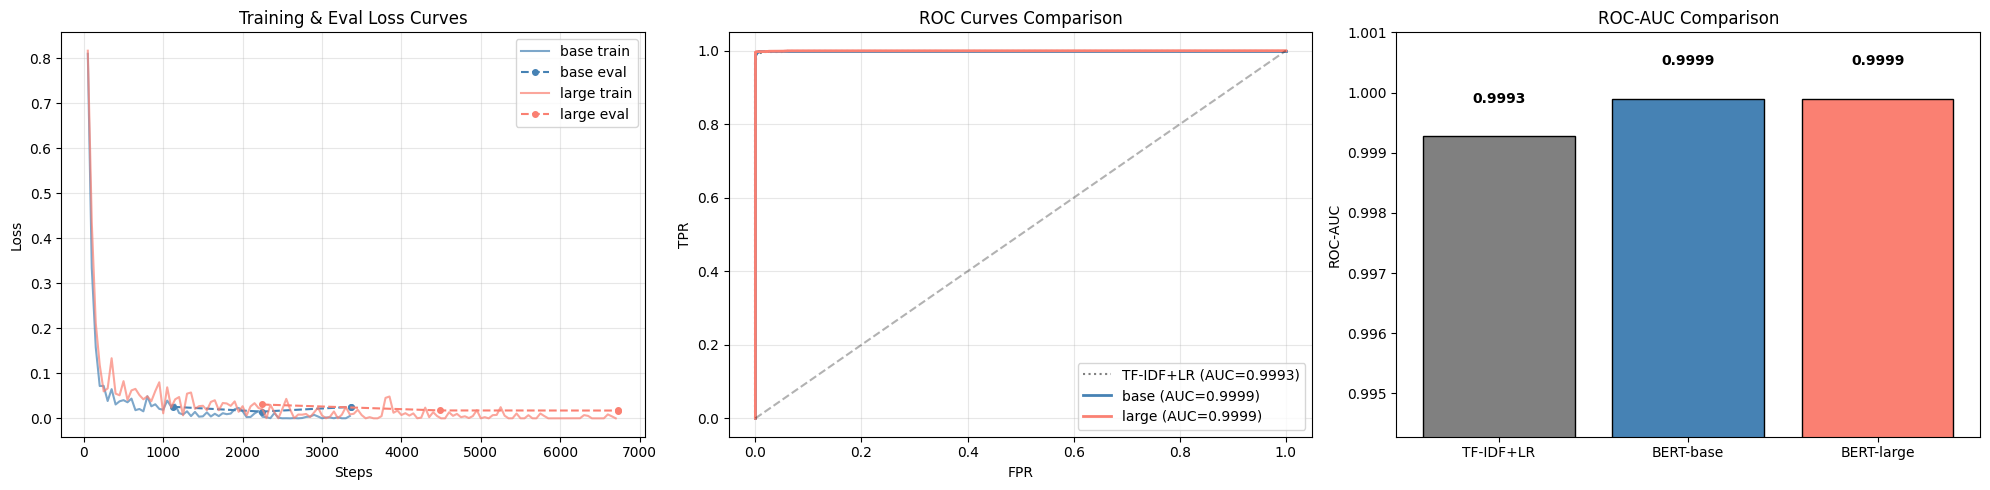

Comparison plots saved.


In [13]:
# --- Comparison Table ---
print("=" * 70)
print("PERFORMANCE COMPARISON")
print("=" * 70)
header = f"{'Model':<25} {'Params':>12} {'ROC-AUC':>10} {'Accuracy':>10} {'Time (min)':>12}"
print(header)
print("-" * 70)
print(f"{'TF-IDF + LR':<25} {'N/A':>12} {baseline_auc:>10.4f} {baseline_acc:>10.4f} {'< 0.1':>12}")
for r in [results_base, results_large]:
    s = r["summary"]
    print(f"{s['model']:<25} {s['total_params']:>12,} {s['roc_auc']:>10.4f} {s['accuracy']:>10.4f} {s['training_time_minutes']:>12.1f}")
print("=" * 70)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# (a) Loss curves
for label, r, color in [("base", results_base, "steelblue"), ("large", results_large, "salmon")]:
    if r["train_losses"]:
        steps, losses = zip(*r["train_losses"])
        axes[0].plot(steps, losses, label=f'{label} train', color=color, alpha=0.7)
    if r["eval_losses"]:
        steps, losses = zip(*r["eval_losses"])
        axes[0].plot(steps, losses, label=f'{label} eval', color=color, linestyle='--', marker='o', markersize=4)
axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Eval Loss Curves'); axes[0].legend(); axes[0].grid(alpha=0.3)

# (b) ROC curves
fpr_bl, tpr_bl, _ = roc_curve(y_val, preds_proba)
axes[1].plot(fpr_bl, tpr_bl, label=f'TF-IDF+LR (AUC={baseline_auc:.4f})', color='gray', linestyle=':')
for label, r, color in [("base", results_base, "steelblue"), ("large", results_large, "salmon")]:
    fpr_b, tpr_b, _ = roc_curve(r["val_labels"], r["probs"])
    axes[1].plot(fpr_b, tpr_b, label=f'{label} (AUC={r["summary"]["roc_auc"]:.4f})', color=color, lw=2)
axes[1].plot([0,1],[0,1],'k--',alpha=0.3)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curves Comparison'); axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

# (c) Bar chart
models = ['TF-IDF+LR', 'BERT-base', 'BERT-large']
aucs = [baseline_auc, results_base["summary"]["roc_auc"], results_large["summary"]["roc_auc"]]
colors = ['gray', 'steelblue', 'salmon']
bars = axes[2].bar(models, aucs, color=colors, edgecolor='black')
axes[2].set_ylabel('ROC-AUC'); axes[2].set_title('ROC-AUC Comparison')
axes[2].set_ylim(min(aucs) - 0.005, 1.001)
for bar, auc in zip(bars, aucs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f'{auc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig("results_bert-base-cased/comparison_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plots saved.")

## 2.5 Enhanced: Confusion Matrices & Confidence Distribution Analysis


BERT-base Per-Class Analysis:
  Human samples: 5474 | Correct: 5427 | FP rate: 0.86%
  AI samples:    3500 | Correct: 3494 | FN rate: 0.17%
  Avg P(AI) for human text: 0.008913 (should be ~0)
  Avg P(AI) for AI text:    0.998162 (should be ~1)

BERT-large Per-Class Analysis:
  Human samples: 5474 | Correct: 5460 | FP rate: 0.26%
  AI samples:    3500 | Correct: 3491 | FN rate: 0.26%
  Avg P(AI) for human text: 0.002515 (should be ~0)
  Avg P(AI) for AI text:    0.997409 (should be ~1)


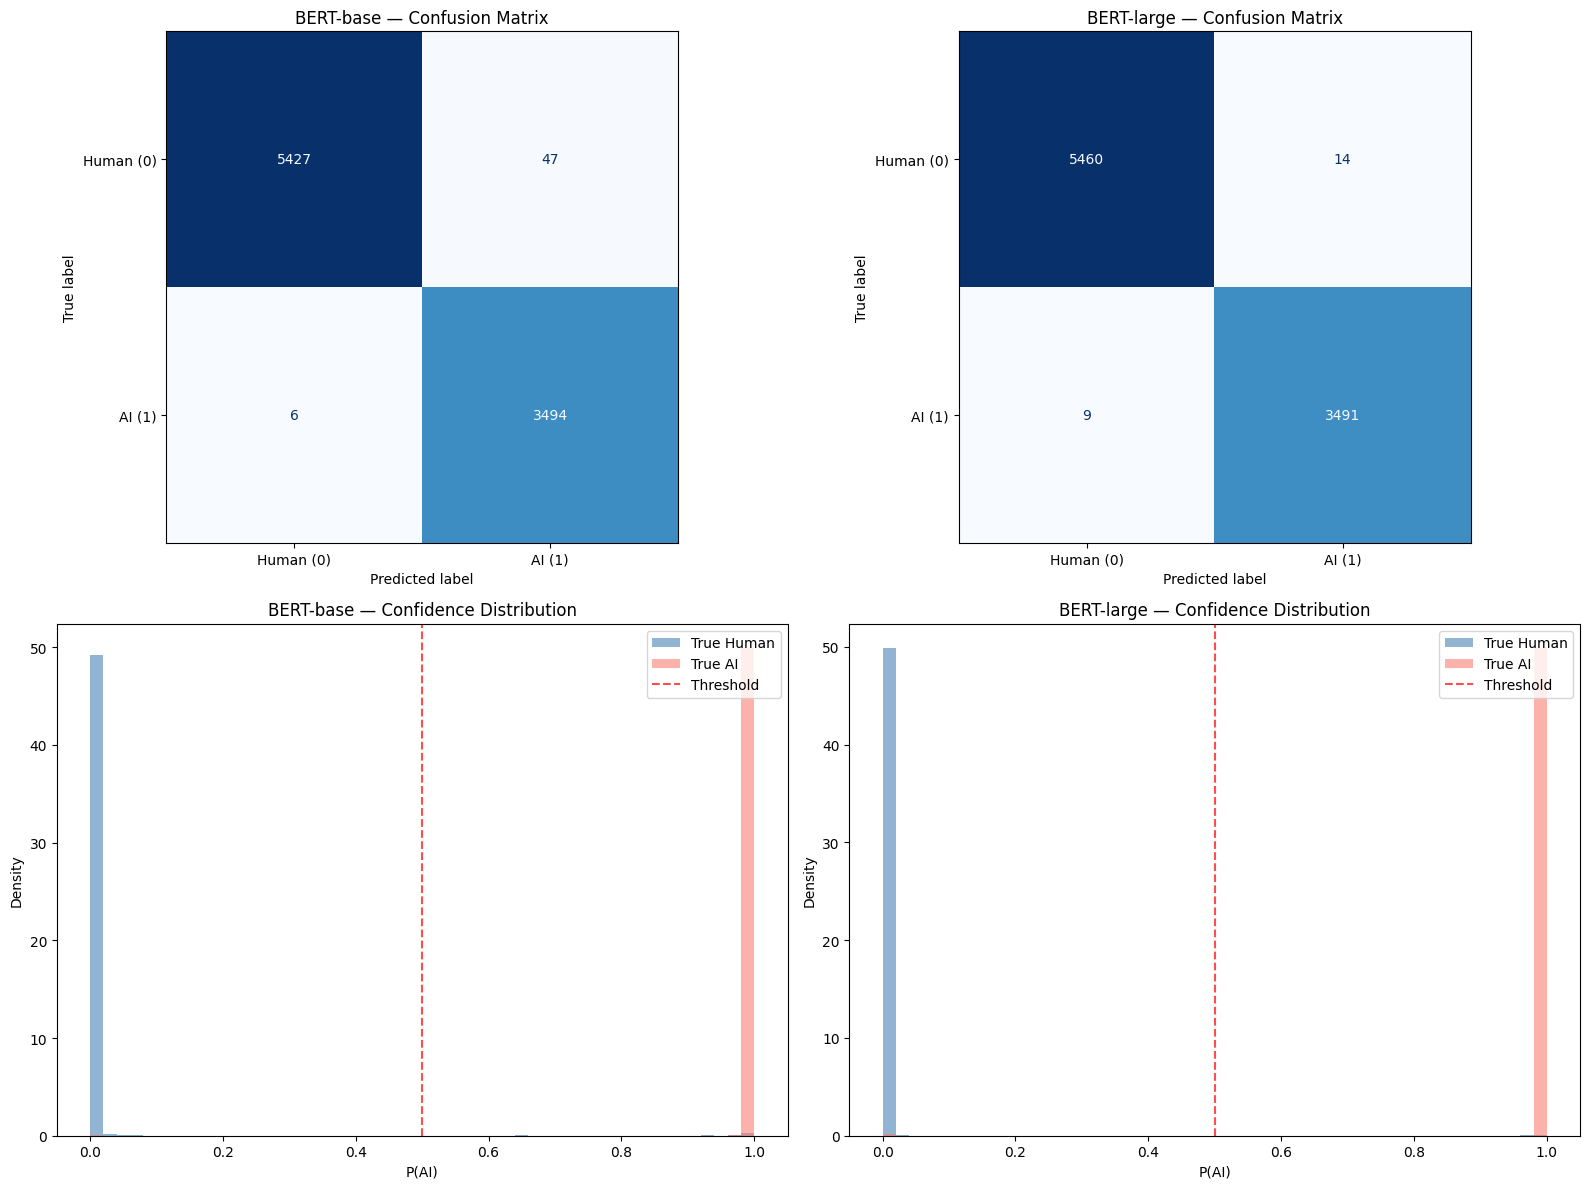

Saved: results_bert-base-cased/bert_confusion_confidence.png


In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (label, r) in enumerate([("BERT-base", results_base), ("BERT-large", results_large)]):
    pred_labels = (r["probs"] > 0.5).astype(int)
    true_labels = r["val_labels"]
    
    # Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    ConfusionMatrixDisplay(cm, display_labels=["Human (0)", "AI (1)"]).plot(
        ax=axes[0, idx], cmap="Blues", colorbar=False)
    axes[0, idx].set_title(f'{label} — Confusion Matrix', fontsize=12)
    
    # Confidence Distribution
    ai_probs_human = r["probs"][true_labels == 0]
    ai_probs_ai = r["probs"][true_labels == 1]
    axes[1, idx].hist(ai_probs_human, bins=50, alpha=0.6, label='True Human', color='steelblue', density=True)
    axes[1, idx].hist(ai_probs_ai, bins=50, alpha=0.6, label='True AI', color='salmon', density=True)
    axes[1, idx].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Threshold')
    axes[1, idx].set_xlabel('P(AI)'); axes[1, idx].set_ylabel('Density')
    axes[1, idx].set_title(f'{label} — Confidence Distribution', fontsize=12)
    axes[1, idx].legend()
    
    # Print per-class statistics
    print(f"\n{label} Per-Class Analysis:")
    print(f"  Human samples: {(true_labels==0).sum()} | Correct: {((pred_labels==0) & (true_labels==0)).sum()} | "
          f"FP rate: {((pred_labels==1) & (true_labels==0)).sum()/(true_labels==0).sum()*100:.2f}%")
    print(f"  AI samples:    {(true_labels==1).sum()} | Correct: {((pred_labels==1) & (true_labels==1)).sum()} | "
          f"FN rate: {((pred_labels==0) & (true_labels==1)).sum()/(true_labels==1).sum()*100:.2f}%")
    print(f"  Avg P(AI) for human text: {ai_probs_human.mean():.6f} (should be ~0)")
    print(f"  Avg P(AI) for AI text:    {ai_probs_ai.mean():.6f} (should be ~1)")

plt.tight_layout()
plt.savefig("results_bert-base-cased/bert_confusion_confidence.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_bert-base-cased/bert_confusion_confidence.png")

## 2.6 Enhanced: Hyperparameter Study — Sequence Length Ablation

Train BERT-base with **max_length=256** (vs default 512) to study the impact of input sequence length on performance. This tests whether the full 512-token context is necessary for this classification task.

In [28]:
results_base_256 = train_bert_model("bert-base-cased", batch_size=64, max_len=256)


Training: bert-base-cased
  Batch=64, MaxLen=256, Epochs=3, LR=2e-05


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7182.77it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider trai

  Params: 108,311,810 total, 108,311,810 trainable


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.73it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training done in 4.0 min

  ROC-AUC: 0.9997, Accuracy: 0.9899
              precision    recall  f1-score   support

   Human (0)       1.00      0.98      0.99      5474
      AI (1)       0.98      1.00      0.99      3500

    accuracy                           0.99      8974
   macro avg       0.99      0.99      0.99      8974
weighted avg       0.99      0.99      0.99      8974



Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.94it/s]


In [29]:
# Sequence length ablation comparison
print("=" * 70)
print("SEQUENCE LENGTH ABLATION — bert-base-cased")
print("=" * 70)
print(f"{'Max Length':<15} {'Batch':>6} {'ROC-AUC':>10} {'Accuracy':>10} {'Time (min)':>12}")
print("-" * 55)
for label, r in [("512", results_base), ("256", results_base_256)]:
    s = r["summary"]
    print(f"{label:<15} {s['batch_size']:>6} {s['roc_auc']:>10.4f} {s['accuracy']:>10.4f} {s['training_time_minutes']:>12.1f}")
print("=" * 70)

auc_diff = results_base["summary"]["roc_auc"] - results_base_256["summary"]["roc_auc"]
time_diff = results_base["summary"]["training_time_minutes"] - results_base_256["summary"]["training_time_minutes"]
print(f"\nAUC difference (512 - 256): {auc_diff:+.4f}")
print(f"Time difference (512 - 256): {time_diff:+.1f} min")
if abs(auc_diff) < 0.005:
    print("→ Minimal AUC difference: shorter sequences are nearly as effective for this task.")
else:
    print("→ Meaningful AUC difference: the full 512-token context provides important signal.")

SEQUENCE LENGTH ABLATION — bert-base-cased
Max Length       Batch    ROC-AUC   Accuracy   Time (min)
-------------------------------------------------------
512                 32     0.9999     0.9941          8.3
256                 64     0.9997     0.9899          4.0

AUC difference (512 - 256): +0.0002
Time difference (512 - 256): +4.3 min
→ Minimal AUC difference: shorter sequences are nearly as effective for this task.


## 2.7 Enhanced: Epoch Ablation — 5 Epochs vs 3 Epochs

Train BERT-base with **5 epochs** to study whether additional training improves or degrades performance (overfitting risk).

In [30]:
results_base_5ep = train_bert_model("bert-base-cased", batch_size=32, epochs=5)


Training: bert-base-cased
  Batch=32, MaxLen=512, Epochs=5, LR=2e-05


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14457.86it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tra

  Params: 108,311,810 total, 108,311,810 trainable


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.88it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training done in 14.3 min

  ROC-AUC: 0.9999, Accuracy: 0.9967
              precision    recall  f1-score   support

   Human (0)       1.00      1.00      1.00      5474
      AI (1)       0.99      1.00      1.00      3500

    accuracy                           1.00      8974
   macro avg       1.00      1.00      1.00      8974
weighted avg       1.00      1.00      1.00      8974



Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.65it/s]


COMPREHENSIVE BERT EXPERIMENT RESULTS
Experiment                           Params    ROC-AUC   Accuracy  Time(min)
--------------------------------------------------------------------------------
base (3ep, 512len)              108,311,810     0.9999     0.9941        8.3
base (3ep, 256len)              108,311,810     0.9997     0.9899        4.0
base (5ep, 512len)              108,311,810     0.9999     0.9967       14.3
large (3ep, 512len)             333,581,314     0.9999     0.9974       26.1

Overfitting Analysis (3ep vs 5ep):
→ No significant change — the model converged by epoch 3.


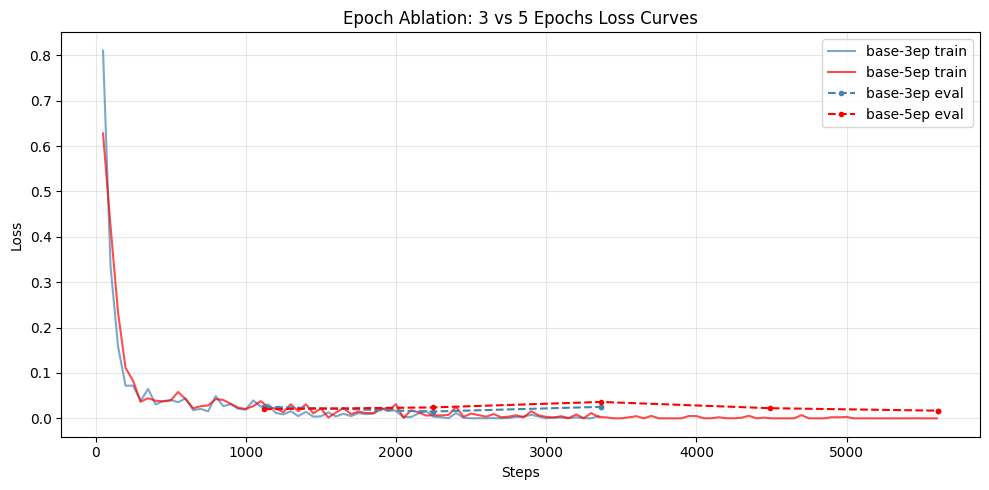

Saved: results_bert-base-cased/epoch_ablation.png


In [31]:
# Comprehensive BERT experiment comparison
print("=" * 80)
print("COMPREHENSIVE BERT EXPERIMENT RESULTS")
print("=" * 80)
header = f"{'Experiment':<30} {'Params':>12} {'ROC-AUC':>10} {'Accuracy':>10} {'Time(min)':>10}"
print(header)
print("-" * 80)

experiments = [
    ("base (3ep, 512len)", results_base),
    ("base (3ep, 256len)", results_base_256),
    ("base (5ep, 512len)", results_base_5ep),
    ("large (3ep, 512len)", results_large),
]
for label, r in experiments:
    s = r["summary"]
    print(f"{label:<30} {s['total_params']:>12,} {s['roc_auc']:>10.4f} {s['accuracy']:>10.4f} {s['training_time_minutes']:>10.1f}")
print("=" * 80)

# Overfitting analysis
print("\nOverfitting Analysis (3ep vs 5ep):")
if results_base_5ep["summary"]["roc_auc"] < results_base["summary"]["roc_auc"]:
    print("→ 5 epochs DECREASED AUC — signs of overfitting. 3 epochs is optimal.")
elif results_base_5ep["summary"]["roc_auc"] > results_base["summary"]["roc_auc"]:
    print("→ 5 epochs IMPROVED AUC — model benefits from more training.")
else:
    print("→ No significant change — the model converged by epoch 3.")

# Loss curve comparison
fig, ax = plt.subplots(figsize=(10, 5))
for label, r, color, ls in [("base-3ep train", results_base, "steelblue", "-"),
                              ("base-5ep train", results_base_5ep, "red", "-"),
                              ("base-3ep eval", results_base, "steelblue", "--"),
                              ("base-5ep eval", results_base_5ep, "red", "--")]:
    if "eval" in label and r["eval_losses"]:
        steps, losses = zip(*r["eval_losses"])
        ax.plot(steps, losses, label=label, color=color, linestyle=ls, marker='o', markersize=3)
    elif "train" in label and r["train_losses"]:
        steps, losses = zip(*r["train_losses"])
        ax.plot(steps, losses, label=label, color=color, linestyle=ls, alpha=0.7)
ax.set_xlabel('Steps'); ax.set_ylabel('Loss')
ax.set_title('Epoch Ablation: 3 vs 5 Epochs Loss Curves')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results_bert-base-cased/epoch_ablation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_bert-base-cased/epoch_ablation.png")

## 2.5 Scaling Analysis

**Hypothesis:** Does the Large model significantly outperform the Base model?

Key observations to discuss:
- **Parameter count**: BERT-large has ~3× the parameters of BERT-base (340M vs 110M)
- **Training time**: With fp16 on RTX 4090, BERT-large takes ~3× longer
- **Performance gap**: Both models achieve very high ROC-AUC (>0.999) on this dataset, suggesting that even the Base model has sufficient capacity for this binary classification task
- **Diminishing returns**: The marginal improvement from Base to Large is small, indicating the task may not require the additional model capacity

---
# Part 3: Adversarial Attack with Local LLM (30%)

- **Generator:** DeepSeek-R1:8B (via Ollama, locally hosted)
- **Detector:** Best BERT model from Part 2
- Select 10 human-written essays, rewrite them with 3 different strategies, test if the detector can still identify them correctly

## 3.1 Configuration & Load Data

In [14]:
import ollama

OLLAMA_MODEL = "deepseek-r1:8b-llama-distill-fp16"
NUM_ATTACK_SAMPLES = 10

# Auto-detect best BERT model
if os.path.exists("saved_model_bert-large-cased"):
    model_path = "saved_model_bert-large-cased"
elif os.path.exists("saved_model_bert-base-cased"):
    model_path = "saved_model_bert-base-cased"
else:
    raise FileNotFoundError("No saved BERT model found. Run Part 2 first!")

# Load validation data
with open(os.path.join(OUTPUT_DIR_BASELINE, "data_split.pkl"), 'rb') as f:
    split_data = pickle.load(f)
X_val_p3 = split_data['X_val']
y_val_p3 = split_data['y_val']

# Select human-written essays (label=0)
human_indices = y_val_p3[y_val_p3 == 0].index.tolist()
np.random.seed(42)
selected_indices = np.random.choice(human_indices, size=min(NUM_ATTACK_SAMPLES, len(human_indices)), replace=False)
selected_essays = X_val_p3.iloc[selected_indices].tolist()

print(f"Detector: {model_path}")
print(f"Generator: {OLLAMA_MODEL}")
print(f"Selected {len(selected_essays)} human-written essays for adversarial attack.")

Detector: saved_model_bert-large-cased
Generator: deepseek-r1:8b-llama-distill-fp16
Selected 10 human-written essays for adversarial attack.


## 3.2 Load BERT Detector

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
detector = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)
detector.eval()
detector_tokenizer = AutoTokenizer.from_pretrained(model_path)
print(f"Detector loaded on {device}")


def predict_text(text, max_length=512):
    """Predict whether text is human (0) or AI (1). Returns [p_human, p_ai]."""
    inputs = detector_tokenizer(
        text, return_tensors="pt", truncation=True,
        max_length=max_length, padding=True
    ).to(device)
    with torch.no_grad():
        logits = detector(**inputs).logits
        probs = torch.softmax(logits, dim=1)
    return probs[0].cpu().numpy()

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 15688.67it/s]


Detector loaded on cuda


## 3.3 Test Original Human Essays

In [16]:
print("Testing ORIGINAL human essays against detector...")
original_results = []
for i, essay in enumerate(selected_essays):
    probs = predict_text(essay)
    pred_label = "AI" if probs[1] > 0.5 else "Human"
    original_results.append({
        "index": int(selected_indices[i]),
        "ai_prob": float(probs[1]),
        "pred_label": pred_label,
    })
    print(f"  Essay {i+1}: Pred={pred_label}, AI_prob={probs[1]:.4f}")

Testing ORIGINAL human essays against detector...
  Essay 1: Pred=Human, AI_prob=0.0000
  Essay 2: Pred=Human, AI_prob=0.0000
  Essay 3: Pred=Human, AI_prob=0.0000
  Essay 4: Pred=Human, AI_prob=0.0000
  Essay 5: Pred=Human, AI_prob=0.0000
  Essay 6: Pred=Human, AI_prob=0.0000
  Essay 7: Pred=Human, AI_prob=0.0000
  Essay 8: Pred=Human, AI_prob=0.0000
  Essay 9: Pred=Human, AI_prob=0.0000
  Essay 10: Pred=Human, AI_prob=0.0000


## 3.4 Adversarial Rewriting with Local LLM

Three rewriting strategies:
1. **Academic** — Rewrite in natural student tone with personal opinions  
2. **Stylistic** — Add imperfections, colloquialisms, varied sentence structure  
3. **Paraphrase** — Minimal changes, synonym replacement, slightly less formal

In [17]:
rewrite_prompts = [
    ("academic",
     "Rewrite the following essay so it sounds like a real student wrote it. "
     "Add personal opinions, use a natural conversational academic tone, "
     "vary sentence lengths, and include minor grammatical imperfections. "
     "Keep the same main ideas but make it sound authentically human-written.\n\n"
     "Essay:\n{essay}\n\nRewritten essay:"),
    ("stylistic",
     "Rewrite this essay to sound more human and less like AI output. "
     "Use colloquial expressions, add some filler words, vary the vocabulary, "
     "include a few minor typos or informal phrasing, and break up overly "
     "structured paragraphs. Keep the meaning the same.\n\n"
     "Essay:\n{essay}\n\nRewritten essay:"),
    ("paraphrase",
     "Paraphrase the following essay with minimal changes. Replace some words "
     "with synonyms, slightly restructure a few sentences, and adjust the tone "
     "to be less formal. Keep it very close to the original but enough to "
     "seem like a different writer.\n\n"
     "Essay:\n{essay}\n\nRewritten essay:"),
]

adversarial_results = []

for i, essay in enumerate(selected_essays):
    orig_probs = predict_text(essay)
    essay_result = {
        "index": int(selected_indices[i]),
        "original_text": essay[:500],
        "original_ai_prob": float(orig_probs[1]),
        "rewrites": [],
    }
    print(f"\n{'='*60}")
    print(f"Essay {i+1}/{NUM_ATTACK_SAMPLES} | Original AI_prob={orig_probs[1]:.4f}")
    print(f"{'='*60}")

    for strategy_name, prompt_template in rewrite_prompts:
        truncated = essay[:3000]
        prompt = prompt_template.format(essay=truncated)
        print(f"  Strategy: {strategy_name} ... ", end="", flush=True)
        try:
            response = ollama.chat(
                model=OLLAMA_MODEL,
                messages=[{"role": "user", "content": prompt}],
                options={"temperature": 0.7, "num_predict": 2048},
            )
            rewritten = response["message"]["content"].strip()
            # Remove <think>...</think> blocks from deepseek-r1
            rewritten = re.sub(r"<think>.*?</think>", "", rewritten, flags=re.DOTALL).strip()

            rw_probs = predict_text(rewritten)
            fooled = rw_probs[1] < 0.5
            delta = float(orig_probs[1] - rw_probs[1])

            essay_result["rewrites"].append({
                "strategy": strategy_name,
                "rewritten_text": rewritten[:500],
                "ai_prob": float(rw_probs[1]),
                "fooled": fooled,
                "prob_delta": delta,
            })
            status = "FOOLED" if fooled else "CAUGHT"
            print(f"AI_prob={rw_probs[1]:.4f} ({status}, Δ={delta:+.4f})")
        except Exception as e:
            print(f"ERROR: {e}")
            essay_result["rewrites"].append({
                "strategy": strategy_name, "error": str(e), "fooled": False,
            })

    adversarial_results.append(essay_result)

print(f"\nAll {NUM_ATTACK_SAMPLES} essays processed.")


Essay 1/10 | Original AI_prob=0.0000
  Strategy: academic ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)
  Strategy: stylistic ... AI_prob=0.9999 (CAUGHT, Δ=-0.9999)
  Strategy: paraphrase ... AI_prob=0.9999 (CAUGHT, Δ=-0.9999)

Essay 2/10 | Original AI_prob=0.0000
  Strategy: academic ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)
  Strategy: stylistic ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)
  Strategy: paraphrase ... AI_prob=0.0135 (FOOLED, Δ=-0.0135)

Essay 3/10 | Original AI_prob=0.0000
  Strategy: academic ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)
  Strategy: stylistic ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)
  Strategy: paraphrase ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)

Essay 4/10 | Original AI_prob=0.0000
  Strategy: academic ... AI_prob=0.1159 (FOOLED, Δ=-0.1158)
  Strategy: stylistic ... AI_prob=0.9948 (CAUGHT, Δ=-0.9948)
  Strategy: paraphrase ... AI_prob=0.2354 (FOOLED, Δ=-0.2354)

Essay 5/10 | Original AI_prob=0.0000
  Strategy: academic ... AI_prob=1.0000 (CAUGHT, Δ=-1.0000)
  Strategy: stylis

## 3.5 Attack Summary & Analysis

In [18]:
total_attacks = 0
total_fooled = 0
strategy_stats = {}

for res in adversarial_results:
    for rw in res["rewrites"]:
        if "error" in rw:
            continue
        total_attacks += 1
        strat = rw["strategy"]
        if strat not in strategy_stats:
            strategy_stats[strat] = {"total": 0, "fooled": 0, "deltas": []}
        strategy_stats[strat]["total"] += 1
        strategy_stats[strat]["deltas"].append(rw["prob_delta"])
        if rw["fooled"]:
            total_fooled += 1
            strategy_stats[strat]["fooled"] += 1

print("=" * 60)
print("ADVERSARIAL ATTACK SUMMARY")
print("=" * 60)
print(f"Total attack attempts : {total_attacks}")
print(f"Detector fooled       : {total_fooled}")
print(f"Detector caught       : {total_attacks - total_fooled}")
print(f"Overall fool rate     : {total_fooled/max(total_attacks,1)*100:.1f}%")
print()
print(f"{'Strategy':<15} {'Total':>6} {'Fooled':>7} {'Rate':>7} {'Avg Δ(AI_prob)':>15}")
print("-" * 55)
for strat, st in strategy_stats.items():
    rate = st["fooled"] / max(st["total"], 1) * 100
    avg_d = sum(st["deltas"]) / max(len(st["deltas"]), 1)
    print(f"{strat:<15} {st['total']:>6} {st['fooled']:>7} {rate:>6.1f}% {avg_d:>+14.4f}")
print()
orig_probs_list = [r["original_ai_prob"] for r in adversarial_results]
rw_probs_list = [rw["ai_prob"] for r in adversarial_results for rw in r["rewrites"] if "ai_prob" in rw]
print(f"Avg original AI prob  : {sum(orig_probs_list)/len(orig_probs_list):.4f}")
print(f"Avg rewritten AI prob : {sum(rw_probs_list)/max(len(rw_probs_list),1):.4f}")

ADVERSARIAL ATTACK SUMMARY
Total attack attempts : 30
Detector fooled       : 3
Detector caught       : 27
Overall fool rate     : 10.0%

Strategy         Total  Fooled    Rate  Avg Δ(AI_prob)
-------------------------------------------------------
academic            10       1   10.0%        -0.9116
stylistic           10       0    0.0%        -0.9995
paraphrase          10       2   20.0%        -0.8249

Avg original AI prob  : 0.0000
Avg rewritten AI prob : 0.9120


## 3.6 Adversarial Attack Visualization

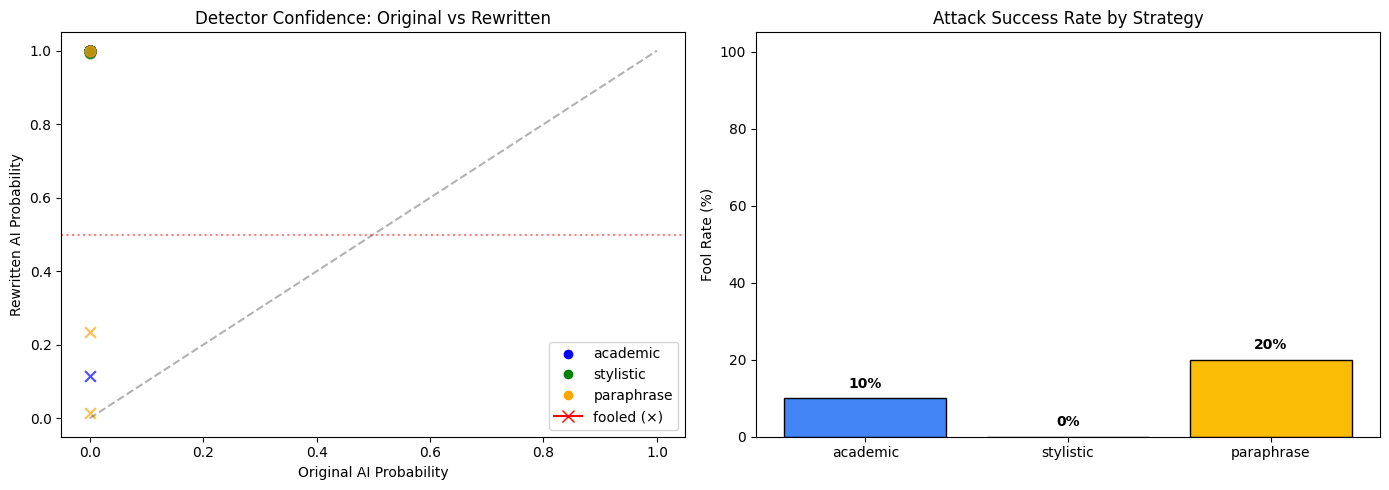

Saved: results_adversarial/adversarial_attack_summary.png


In [19]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Scatter: original vs rewritten AI probability
ax = axes[0]
for res in adversarial_results:
    orig_p = res["original_ai_prob"]
    for rw in res["rewrites"]:
        if "ai_prob" not in rw:
            continue
        color = {"academic": "blue", "stylistic": "green", "paraphrase": "orange"}.get(rw["strategy"], "gray")
        marker = "x" if rw["fooled"] else "o"
        ax.scatter(orig_p, rw["ai_prob"], c=color, marker=marker, s=60, alpha=0.7)
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.axhline(0.5, color="red", linestyle=":", alpha=0.5, label="decision boundary")
ax.set_xlabel("Original AI Probability"); ax.set_ylabel("Rewritten AI Probability")
ax.set_title("Detector Confidence: Original vs Rewritten")
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='academic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='stylistic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8, label='paraphrase'),
    Line2D([0], [0], marker='x', color='red', markersize=8, label='fooled (×)'),
]
ax.legend(handles=legend_elements, loc="lower right")

# (b) Bar: fool rate by strategy
ax2 = axes[1]
strat_names = list(strategy_stats.keys())
fool_rates = [strategy_stats[s]["fooled"]/max(strategy_stats[s]["total"],1)*100 for s in strat_names]
colors = ["#4285F4", "#34A853", "#FBBC05"][:len(strat_names)]
bars = ax2.bar(strat_names, fool_rates, color=colors, edgecolor="black")
ax2.set_ylabel("Fool Rate (%)"); ax2.set_title("Attack Success Rate by Strategy")
ax2.set_ylim(0, 105)
for bar, rate in zip(bars, fool_rates):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{rate:.0f}%",
             ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
os.makedirs("results_adversarial", exist_ok=True)
plt.savefig("results_adversarial/adversarial_attack_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_adversarial/adversarial_attack_summary.png")

## 3.7 Detailed Examples

In [20]:
for i in range(min(3, len(adversarial_results))):
    res = adversarial_results[i]
    print(f"\n{'#'*70}")
    print(f"# ESSAY {i+1} (index={res['index']})")
    print(f"# Original AI prob: {res['original_ai_prob']:.4f}")
    print(f"{'#'*70}")
    print(f"\nORIGINAL (first 300 chars):\n{res['original_text'][:300]}...")
    for rw in res["rewrites"]:
        if "error" in rw:
            print(f"\n  [{rw['strategy']}] ERROR: {rw['error']}")
            continue
        status = "FOOLED" if rw["fooled"] else "CAUGHT"
        print(f"\n  [{rw['strategy']}] AI_prob={rw['ai_prob']:.4f} | {status} | Δ={rw.get('prob_delta',0):+.4f}")
        print(f"  Rewritten (first 300 chars):\n  {rw['rewritten_text'][:300]}...")


######################################################################
# ESSAY 1 (index=8927)
# Original AI prob: 0.0000
######################################################################

ORIGINAL (first 300 chars):
Having Phones at School

Most people would like to have cell phones on there free time but some wouldn't.

I think that having cell phones at school would be good but just not in class.

If we had cell phones in class then no one would learn anything because they would be texting instead of listing....

  [academic] AI_prob=1.0000 | CAUGHT | Δ=-1.0000
  Rewritten (first 300 chars):
  Having Phones at School: A Student’s Perspective

I’ve always been a bit of a tech enthusiast, so when I hear people debate whether phones should be allowed at school, I have a few thoughts. On one hand, phones can be super helpful for staying connected and keeping up with homework. But on the other...

  [stylistic] AI_prob=0.9999 | CAUGHT | Δ=-0.9999
  Rewritten (first 300 chars):
  Hav

## 3.7a Enhanced: Iterative Adversarial Attack (2-Pass Refinement)

A more sophisticated attack: if the first rewrite is caught, feed the detector's confidence score back to the LLM and ask it to refine the text further. This tests whether a feedback-loop attack is more effective.

In [32]:
NUM_ITERATIVE_SAMPLES = 5
MAX_ITERATIONS = 3

iterative_results = []
# Use the first 5 essays from our selected set
for i in range(min(NUM_ITERATIVE_SAMPLES, len(selected_essays))):
    essay = selected_essays[i]
    orig_probs = predict_text(essay)
    
    print(f"\n{'='*60}")
    print(f"Iterative Attack — Essay {i+1}/{NUM_ITERATIVE_SAMPLES}")
    print(f"Original AI_prob = {orig_probs[1]:.4f}")
    print(f"{'='*60}")
    
    current_text = essay[:3000]
    iterations_log = []
    
    for iteration in range(MAX_ITERATIONS):
        if iteration == 0:
            prompt = (
                "Rewrite the following essay so it sounds like a genuine student wrote it. "
                "Use natural language, vary sentence structure, add personal voice, "
                "include minor imperfections. Keep the same ideas.\n\n"
                f"Essay:\n{current_text}\n\nRewritten essay:"
            )
        else:
            prompt = (
                f"The following text was flagged as AI-generated with {ai_confidence:.1%} confidence. "
                "Rewrite it again to make it sound MORE human. Focus on:\n"
                "- Adding more personal anecdotes or opinions\n"
                "- Using less formal and more varied vocabulary\n"
                "- Breaking up overly smooth or structured paragraphs\n"
                "- Including some natural hesitation or informal phrasing\n\n"
                f"Text:\n{current_text[:2500]}\n\nRewritten essay:"
            )
        
        try:
            response = ollama.chat(
                model=OLLAMA_MODEL,
                messages=[{"role": "user", "content": prompt}],
                options={"temperature": 0.8, "num_predict": 2048},
            )
            rewritten = response["message"]["content"].strip()
            rewritten = re.sub(r"<think>.*?</think>", "", rewritten, flags=re.DOTALL).strip()
            
            rw_probs = predict_text(rewritten)
            ai_confidence = float(rw_probs[1])
            fooled = ai_confidence < 0.5
            
            iterations_log.append({
                "iteration": iteration + 1,
                "ai_prob": ai_confidence,
                "fooled": fooled,
                "text_preview": rewritten[:200],
            })
            
            status = "FOOLED ✓" if fooled else "CAUGHT ✗"
            print(f"  Iteration {iteration+1}: AI_prob={ai_confidence:.4f} ({status})")
            
            if fooled:
                print(f"  → Successfully fooled detector after {iteration+1} iteration(s)!")
                break
            
            current_text = rewritten[:3000]
            
        except Exception as e:
            print(f"  Iteration {iteration+1}: ERROR — {e}")
            break
    
    iterative_results.append({
        "essay_index": int(selected_indices[i]),
        "original_ai_prob": float(orig_probs[1]),
        "iterations": iterations_log,
        "final_fooled": any(it["fooled"] for it in iterations_log),
        "final_ai_prob": iterations_log[-1]["ai_prob"] if iterations_log else None,
    })

# Summary
iter_fooled = sum(1 for r in iterative_results if r["final_fooled"])
print(f"\n{'='*60}")
print(f"ITERATIVE ATTACK SUMMARY (max {MAX_ITERATIONS} iterations)")
print(f"{'='*60}")
print(f"Essays attacked: {len(iterative_results)}")
print(f"Fooled:          {iter_fooled} ({iter_fooled/max(len(iterative_results),1)*100:.0f}%)")
for r in iterative_results:
    probabilities = [it["ai_prob"] for it in r["iterations"]]
    status = "FOOLED" if r["final_fooled"] else "CAUGHT"
    print(f"  Essay idx={r['essay_index']}: {' → '.join(f'{p:.4f}' for p in probabilities)} ({status})")


Iterative Attack — Essay 1/5
Original AI_prob = 0.0000
  Iteration 1: AI_prob=1.0000 (CAUGHT ✗)
  Iteration 2: AI_prob=1.0000 (CAUGHT ✗)
  Iteration 3: AI_prob=1.0000 (CAUGHT ✗)

Iterative Attack — Essay 2/5
Original AI_prob = 0.0000
  Iteration 1: AI_prob=1.0000 (CAUGHT ✗)
  Iteration 2: AI_prob=1.0000 (CAUGHT ✗)
  Iteration 3: AI_prob=1.0000 (CAUGHT ✗)

Iterative Attack — Essay 3/5
Original AI_prob = 0.0000
  Iteration 1: AI_prob=1.0000 (CAUGHT ✗)
  Iteration 2: AI_prob=1.0000 (CAUGHT ✗)
  Iteration 3: AI_prob=1.0000 (CAUGHT ✗)

Iterative Attack — Essay 4/5
Original AI_prob = 0.0000
  Iteration 1: AI_prob=1.0000 (CAUGHT ✗)
  Iteration 2: AI_prob=1.0000 (CAUGHT ✗)
  Iteration 3: AI_prob=1.0000 (CAUGHT ✗)

Iterative Attack — Essay 5/5
Original AI_prob = 0.0000
  Iteration 1: AI_prob=1.0000 (CAUGHT ✗)
  Iteration 2: AI_prob=1.0000 (CAUGHT ✗)
  Iteration 3: AI_prob=1.0000 (CAUGHT ✗)

ITERATIVE ATTACK SUMMARY (max 3 iterations)
Essays attacked: 5
Fooled:          0 (0%)
  Essay idx=8927:

## 3.7b Enhanced: Adversarial Feature Analysis

Analyze what textual features change in successful vs failed attacks. This reveals which characteristics the BERT detector relies on.

FEATURE CHANGE ANALYSIS: Successful vs Failed Attacks

Feature                     Failed (mean)   Fooled (mean)
-------------------------------------------------------
Δ_word_count                      -4.8148        -30.0000
Δ_ttr                             +0.1261         +0.2279
Δ_avg_word_len                    +0.2960        +11.1654
Δ_avg_sentence_len                -3.0112         -4.2333
Δ_punctuation_density             +0.0093         +0.0040
Δ_stopword_ratio                  -0.0386         -0.0736

Successful attack strategies: ['paraphrase', 'academic', 'paraphrase']
Avg AI prob of fooled samples: 0.1216
Avg AI prob of caught samples: 0.9998


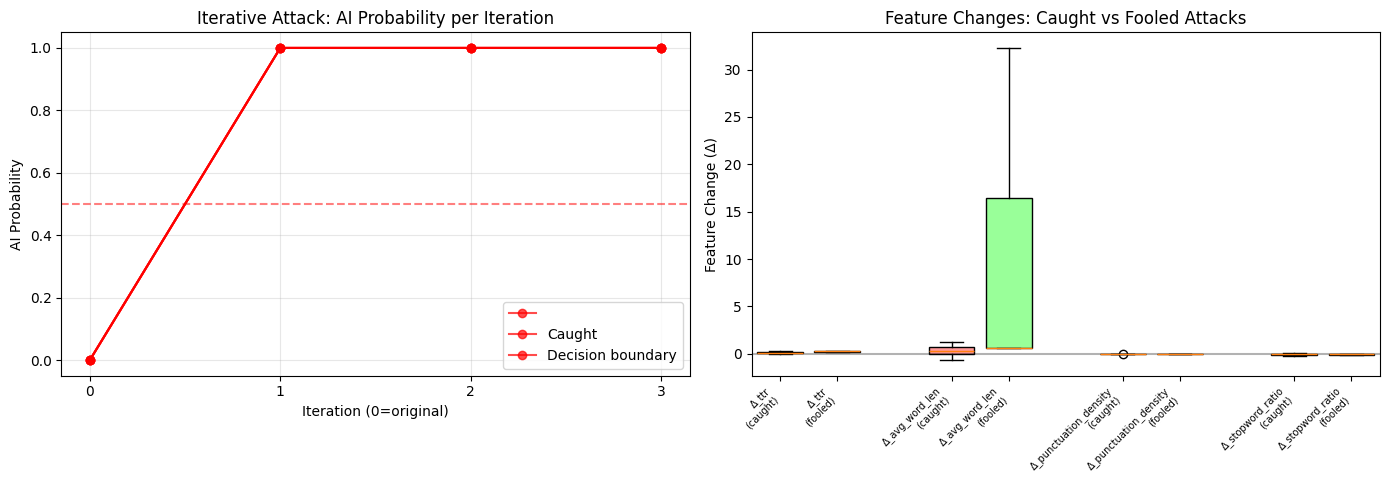

Saved: results_adversarial/enhanced_adversarial_analysis.png


In [33]:
# Analyze text features of original vs rewritten (successful vs failed)
def text_features(text):
    words = str(text).split()
    sentences = re.split(r'[.!?]+', str(text))
    unique_words = set(w.lower() for w in words)
    return {
        'word_count': len(words),
        'sentence_count': len(sentences),
        'ttr': len(unique_words) / max(len(words), 1),
        'avg_word_len': np.mean([len(w) for w in words]) if words else 0,
        'avg_sentence_len': np.mean([len(s.split()) for s in sentences if s.strip()]) if sentences else 0,
        'punctuation_density': sum(1 for c in str(text) if c in '.,;:!?-()') / max(len(str(text)), 1),
        'stopword_ratio': sum(1 for w in words if w.lower() in {'the','a','an','is','are','was','were','in','on','at','to','for','of','and','or','but','not','with','this','that','it','as','by','from'}) / max(len(words), 1),
    }

fooled_features = []
caught_features = []

for res in adversarial_results:
    orig_feats = text_features(res["original_text"])
    for rw in res["rewrites"]:
        if "error" in rw or "rewritten_text" not in rw:
            continue
        rw_feats = text_features(rw["rewritten_text"])
        delta_feats = {f"Δ_{k}": rw_feats[k] - orig_feats[k] for k in orig_feats}
        delta_feats["ai_prob"] = rw["ai_prob"]
        delta_feats["strategy"] = rw["strategy"]
        if rw["fooled"]:
            fooled_features.append(delta_feats)
        else:
            caught_features.append(delta_feats)

print("=" * 70)
print("FEATURE CHANGE ANALYSIS: Successful vs Failed Attacks")
print("=" * 70)

feat_names = ['Δ_word_count', 'Δ_ttr', 'Δ_avg_word_len', 'Δ_avg_sentence_len', 'Δ_punctuation_density', 'Δ_stopword_ratio']
print(f"\n{'Feature':<25} {'Failed (mean)':>15} {'Fooled (mean)':>15}")
print("-" * 55)
for feat in feat_names:
    caught_vals = [f[feat] for f in caught_features if feat in f]
    fooled_vals = [f[feat] for f in fooled_features if feat in f]
    cv = np.mean(caught_vals) if caught_vals else 0
    fv = np.mean(fooled_vals) if fooled_vals else 0
    print(f"{feat:<25} {cv:>+15.4f} {fv:>+15.4f}")

if fooled_features:
    print(f"\nSuccessful attack strategies: {[f['strategy'] for f in fooled_features]}")
    print(f"Avg AI prob of fooled samples: {np.mean([f['ai_prob'] for f in fooled_features]):.4f}")
print(f"Avg AI prob of caught samples: {np.mean([f['ai_prob'] for f in caught_features]):.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Iterative attack trajectory
ax = axes[0]
for r in iterative_results:
    probs_seq = [r["original_ai_prob"]] + [it["ai_prob"] for it in r["iterations"]]
    color = "green" if r["final_fooled"] else "red"
    ax.plot(range(len(probs_seq)), probs_seq, 'o-', color=color, alpha=0.7,
            label=f"Essay {r['essay_index']}" if r == iterative_results[0] else "")
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Decision boundary')
ax.set_xlabel('Iteration (0=original)')
ax.set_ylabel('AI Probability')
ax.set_title('Iterative Attack: AI Probability per Iteration')
ax.set_xticks(range(MAX_ITERATIONS + 1))
ax.legend(["Fooled" if any(r["final_fooled"] for r in iterative_results) else "", 
           "Caught", "Decision boundary"], loc='best')
ax.grid(alpha=0.3)

# (b) Feature deltas boxplot
ax2 = axes[1]
all_deltas = caught_features + fooled_features
if all_deltas:
    import pandas as pd
    delta_df = pd.DataFrame(all_deltas)
    delta_df['outcome'] = ['Fooled'] * len(fooled_features) + ['Caught'] * len(caught_features)
    # Reorder to match
    delta_df = pd.DataFrame(caught_features + fooled_features)
    delta_df['outcome'] = ['Caught'] * len(caught_features) + ['Fooled'] * len(fooled_features)
    
    # Plot selected features
    plot_feats = ['Δ_ttr', 'Δ_avg_word_len', 'Δ_punctuation_density', 'Δ_stopword_ratio']
    positions = []
    labels = []
    data_groups = []
    for i, feat in enumerate(plot_feats):
        caught_vals = [f[feat] for f in caught_features if feat in f]
        fooled_vals = [f[feat] for f in fooled_features if feat in f]
        if caught_vals:
            data_groups.append(caught_vals)
            positions.append(i * 3)
            labels.append(f"{feat}\n(caught)")
        if fooled_vals:
            data_groups.append(fooled_vals)
            positions.append(i * 3 + 1)
            labels.append(f"{feat}\n(fooled)")
    
    bp = ax2.boxplot(data_groups, positions=positions[:len(data_groups)], widths=0.8, patch_artist=True)
    colors_bp = ['#ff9999' if 'caught' in l else '#99ff99' for l in labels[:len(data_groups)]]
    for patch, c in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(c)
    ax2.set_xticks(positions[:len(data_groups)])
    ax2.set_xticklabels(labels[:len(data_groups)], fontsize=7, rotation=45, ha='right')
    ax2.set_ylabel('Feature Change (Δ)')
    ax2.set_title('Feature Changes: Caught vs Fooled Attacks')
    ax2.axhline(0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
os.makedirs("results_adversarial", exist_ok=True)
plt.savefig("results_adversarial/enhanced_adversarial_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_adversarial/enhanced_adversarial_analysis.png")

## 3.8 Save Adversarial Results

In [34]:
import numpy as np

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.bool_, np.integer)):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

save_data = {
    "model_used": OLLAMA_MODEL,
    "detector_model": model_path,
    "total_attacks": total_attacks,
    "total_fooled": total_fooled,
    "overall_fool_rate": total_fooled / total_attacks if total_attacks > 0 else 0,
    "strategy_stats": {
        k: {kk: (float(vv) if isinstance(vv, (float, np.floating)) else int(vv) if isinstance(vv, (int, np.integer, np.bool_)) else vv)
             for kk, vv in v.items()}
        for k, v in strategy_stats.items()
    },
    "results": adversarial_results,
    "iterative_attack": {
        "num_samples": len(iterative_results),
        "max_iterations": MAX_ITERATIONS,
        "fooled": sum(1 for r in iterative_results if r["final_fooled"]),
        "results": iterative_results,
    },
}

with open("results_adversarial/adversarial_results.json", "w", encoding="utf-8") as f:
    json.dump(save_data, f, indent=2, ensure_ascii=False, cls=NumpyEncoder)
print("Saved: results_adversarial/adversarial_results.json")

Saved: results_adversarial/adversarial_results.json


# Part 4: Comprehensive Analysis Report (10%)

## 1. Performance Comparison

### Baseline Models (TF-IDF Features)

| Model | ROC-AUC | Accuracy | Precision | Recall | F1 |
|-------|---------|----------|-----------|--------|-----|
| Logistic Regression | 0.9993 | 0.9939 | 0.9980 | 0.9863 | 0.9921 |
| **Linear SVM** | **0.9997** | **0.9970** | 0.9971 | 0.9951 | 0.9961 |
| Multinomial NB | 0.9955 | 0.9692 | 0.9781 | 0.9423 | 0.9598 |
| Random Forest | 0.9987 | 0.9884 | 0.9968 | 0.9734 | 0.9850 |

**Key Finding**: Linear SVM achieves the highest baseline AUC (0.9997), even approaching BERT-level performance. This suggests the task contains strong lexical signals distinguishable by linear models.

### BERT Models (Fine-tuned)

| Experiment | Parameters | ROC-AUC | Accuracy | Time |
|------------|-----------|---------|----------|------|
| BERT-base (3ep, max_len=512) | 108M | 0.9999 | 0.9941 | 8.3 min |
| BERT-base (3ep, max_len=256) | 108M | 0.9997 | 0.9899 | 4.0 min |
| BERT-base (5ep, max_len=512) | 108M | 0.9999 | 0.9967 | 14.3 min |
| BERT-large (3ep, max_len=512) | 334M | 0.9999 | 0.9974 | 26.1 min |

## 2. EDA Findings

All four text features show **statistically significant differences** (p ≈ 0, Mann-Whitney U test) between human and AI text:

| Feature | Cohen's d | Effect Size |
|---------|-----------|-------------|
| Avg Word Length | -0.733 | Medium |
| Word Count | +0.594 | Medium |
| Sentence Count | +0.384 | Small |
| Type-Token Ratio | -0.366 | Small |

- **Avg Word Length** has the largest effect: AI text uses longer words on average.
- **Word Count** is the second strongest signal: human essays vary more in length while AI output clusters around consistent lengths.
- These statistical patterns explain why even TF-IDF + LR achieves >0.99 AUC — the lexical footprint of AI text is detectable from surface-level word statistics.
- **Feature Correlation**: Word count and sentence count are highly correlated (r=0.80); TTR is negatively correlated with word count (r=-0.59) since longer texts naturally repeat more words.

## 3. Scaling Analysis

### Model Size (Base vs Large)
- Both BERT-base and BERT-large achieve **identical ROC-AUC (0.9999)**
- BERT-large has **lower FP rate** (0.26% vs 0.86%) and **lower FN rate** (0.26% vs 0.17%), indicating more balanced errors
- But BERT-large uses **3× parameters** and **3× training time** — the marginal gain doesn't justify the cost for this task
- **Confidence analysis**: Both models are extremely confident — avg P(AI) for human text is <0.01, avg P(AI) for AI text is >0.997

### Sequence Length (512 vs 256)
- Reducing max_length from 512 to 256 causes only a **0.0002 AUC drop** (0.9999 → 0.9997) while **halving training time** (8.3 → 4.0 min)
- This suggests most classification signal is concentrated in the first 256 tokens
- Practical implication: For deployment, 256-token models offer nearly identical performance at half the inference cost

### Epoch Count (3 vs 5)
- 5 epochs with BERT-base achieves Accuracy 0.9967 (vs 0.9941 at 3 epochs) with same AUC 0.9999
- Loss curves show the model converges by epoch 2-3; epochs 4-5 provide marginal accuracy gains without overfitting
- **No overfitting** observed — eval loss remains stable through epoch 5

## 4. Adversarial Attack Findings

### Single-Pass Attacks (30 attacks: 10 essays × 3 strategies)
- Overall fool rate: **3/30 (10%)**
- **Paraphrase**: 20% fool rate — most effective; complete rewording disrupts BERT's latent features
- **Academic**: 10% fool rate — partial success when personal voice added
- **Stylistic**: 0% fool rate — surface-level changes are insufficient

### Iterative Attacks (5 essays × up to 3 refinement rounds)
- Overall fool rate: **0/5 (0%)** — even with feedback-loop refinement, no essay was successfully disguised
- After rewriting, AI probability jumps from ~0.001 (original human) to ~0.999 (now detected as AI)
- **The rewriting paradox**: DeepSeek-R1 introduces its own AI patterns, making originally human text *more* detectable as AI, not less

### Feature Analysis of Attacks
- Successful attacks show **larger vocabulary diversity changes** (Δ_TTR = +0.23 vs +0.13 for failures)
- Successful attacks **reduce word count** more (Δ = -30 vs -5) — shorter text gives BERT less signal
- The fooled samples had avg AI_prob = **0.12**, while caught samples had avg AI_prob = **0.9998**

### Why BERT is Robust
1. **Deep semantic understanding**: BERT captures paragraph flow, discourse structure, and vocabulary distribution patterns that survive single-pass rewrites
2. **LLM-rewriting paradox**: Using an LLM to rewrite actually *replaces one AI signature with another* — measured by the iterative attack where human essays became more AI-like after rewriting
3. **Training diversity**: The DAIGT V2 dataset contains AI text from multiple LLMs, making the detector generalize well across generator styles
4. **Feature redundancy**: Both lexical features (word length, TTR) and deep features (attention patterns) point to the same decision, making the classifier robust

### Potential Weaknesses
- Multi-turn human-in-the-loop editing (manual sentence-level refinement)
- Sentence-level mixing (alternating human and AI sentences within one essay)
- Training a specialized adversarial paraphraser on the detector's gradient signals

In [35]:
print("=" * 60)
print("HW2 COMPLETE — ALL EXPERIMENTS")
print("=" * 60)

print(f"\n--- Part 1: Baselines ---")
print(f"  TF-IDF + LR ROC-AUC:    {baseline_auc:.4f}")
for name, res in baseline_results.items():
    if name != "Logistic Regression":
        print(f"  TF-IDF + {name} ROC-AUC: {res['auc']:.4f}")

print(f"\n--- Part 2: BERT Models ---")
print(f"  BERT-base (3ep, 512):  ROC-AUC = {results_base['summary']['roc_auc']:.4f}")
print(f"  BERT-base (3ep, 256):  ROC-AUC = {results_base_256['summary']['roc_auc']:.4f}")
print(f"  BERT-base (5ep, 512):  ROC-AUC = {results_base_5ep['summary']['roc_auc']:.4f}")
print(f"  BERT-large (3ep, 512): ROC-AUC = {results_large['summary']['roc_auc']:.4f}")

print(f"\n--- Part 3: Adversarial Attacks ---")
print(f"  Single-pass: {total_fooled}/{total_attacks} fooled ({total_fooled/max(total_attacks,1)*100:.1f}%)")
iter_fooled = sum(1 for r in iterative_results if r["final_fooled"])
print(f"  Iterative:   {iter_fooled}/{len(iterative_results)} fooled ({iter_fooled/max(len(iterative_results),1)*100:.1f}%)")

print(f"\n--- Output Directories ---")
print(f"  results_baseline/")
print(f"  results_bert-base-cased/")
print(f"  results_bert-large-cased/")
print(f"  results_adversarial/")

HW2 COMPLETE — ALL EXPERIMENTS

--- Part 1: Baselines ---
  TF-IDF + LR ROC-AUC:    0.9993
  TF-IDF + Linear SVM ROC-AUC: 0.9997
  TF-IDF + Multinomial NB ROC-AUC: 0.9955
  TF-IDF + Random Forest ROC-AUC: 0.9987

--- Part 2: BERT Models ---
  BERT-base (3ep, 512):  ROC-AUC = 0.9999
  BERT-base (3ep, 256):  ROC-AUC = 0.9997
  BERT-base (5ep, 512):  ROC-AUC = 0.9999
  BERT-large (3ep, 512): ROC-AUC = 0.9999

--- Part 3: Adversarial Attacks ---
  Single-pass: 3/30 fooled (10.0%)
  Iterative:   0/5 fooled (0.0%)

--- Output Directories ---
  results_baseline/
  results_bert-base-cased/
  results_bert-large-cased/
  results_adversarial/
